---

## **財務比率分析ダッシュボード**

---

企業の財務データを分析するとき、売上高や利益の「金額」だけを見ていても、その会社が本当に健全かどうかはわかりません。

そこで活躍するのが**財務比率**です。貸借対照表（B/S）と損益計算書（P/L）の数字を組み合わせることで、収益性・安全性・効率性を横断的に評価できます。実際の投資家・アナリスト・監査人もこれらの指標を日常的に使っています。

このノートブックでは、架空企業「ABC株式会社」の5年間（2019〜2023年）のデータを使って：

1. **財務データの準備と比率計算** — 貸借対照表・損益計算書から6つの主要指標を算出
2. **多年度トレンドの可視化** — 時系列グラフで経営の変化を読み取る
3. **レーダーチャートと健全性スコア** — 会社全体の財務健全性を一目で把握

を順に見ていきましょう。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import logging

warnings.simplefilter('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

sns.set(style="darkgrid")

_jp_fonts = [f.name for f in fm.fontManager.ttflist
             if any(k in f.name for k in ['Gothic', 'Mincho', 'CJK', 'Noto', 'IPA', 'Meiryo', 'Yu'])]
if _jp_fonts:
    plt.rcParams['font.family'] = _jp_fonts[0]
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'

---

## **1. サンプルデータ — ABC株式会社の財務諸表**

---

今回使うデータは、架空の中堅製造業「ABC株式会社」の2019〜2023年度の財務諸表です。単位は**百万円**です。

主な項目の意味は以下のとおりです：

| 項目 | 説明 |
|------|------|
| 流動資産 | 1年以内に現金化できる資産（現金・売掛金・在庫など） |
| 固定資産 | 設備・不動産など長期保有の資産 |
| 流動負債 | 1年以内に返済が必要な負債（買掛金・短期借入金など） |
| 固定負債 | 長期借入金・社債など |
| 純資産 | 資本金＋利益剰余金（株主に帰属する資産） |
| 売上高 | 製品・サービスの売上合計 |
| 営業利益 | 売上高から売上原価・販管費を引いた本業の利益 |
| 当期純利益 | 税引後の最終利益（マイナスの場合は赤字） |

> ※ 2021年度はコスト増と売上減が重なり、当期純利益が**赤字**になっています。そのあたりで指標がどう変化するかに注目してみてください。

In [2]:
YEARS = [2019, 2020, 2021, 2022, 2023]

# 貸借対照表 (B/S) — 単位: 百万円
bs_data = {
    "年度":     YEARS,
    "流動資産": [3_200, 3_450, 3_100, 3_800, 4_200],
    "固定資産": [5_800, 5_950, 6_100, 6_300, 6_500],
    "流動負債": [2_100, 2_400, 2_600, 2_300, 2_100],
    "固定負債": [2_500, 2_800, 2_900, 2_700, 2_500],
    "純資産":   [4_400, 4_200, 3_700, 5_100, 6_100],
}

# 損益計算書 (P/L) — 単位: 百万円
pl_data = {
    "年度":       YEARS,
    "売上高":     [12_000, 11_500, 10_800, 13_200, 14_800],
    "営業利益":   [   960,    690,    324,  1_188,  1_776],
    "当期純利益": [   600,    350,   -150,    850,  1_300],
}

df_bs = pd.DataFrame(bs_data).set_index("年度")
df_pl = pd.DataFrame(pl_data).set_index("年度")

df_bs["総資産"] = df_bs["流動資産"] + df_bs["固定資産"]
df_bs["総負債"] = df_bs["流動負債"] + df_bs["固定負債"]

print("=== 貸借対照表 (B/S) 単位:百万円 ===")
print(df_bs.to_string())
print()
print("=== 損益計算書 (P/L) 単位:百万円 ===")
print(df_pl.to_string())

=== 貸借対照表 (B/S) 単位:百万円 ===
      流動資産  固定資産  流動負債  固定負債   純資産    総資産   総負債
年度                                             
2019  3200  5800  2100  2500  4400   9000  4600
2020  3450  5950  2400  2800  4200   9400  5200
2021  3100  6100  2600  2900  3700   9200  5500
2022  3800  6300  2300  2700  5100  10100  5000
2023  4200  6500  2100  2500  6100  10700  4600

=== 損益計算書 (P/L) 単位:百万円 ===
        売上高  営業利益  当期純利益
年度                      
2019  12000   960    600
2020  11500   690    350
2021  10800   324   -150
2022  13200  1188    850
2023  14800  1776   1300


---

## **2. 財務比率の計算**

---

財務比率は大きく「**安全性指標**」と「**収益性指標**」に分けられます。

### 安全性指標（お金がきちんと回っているか？）

$$\text{流動比率} = \frac{\text{流動資産}}{\text{流動負債}} \times 100 \quad (\text{目安: } \geq 150\%)$$

$$\text{自己資本比率} = \frac{\text{純資産}}{\text{総資産}} \times 100 \quad (\text{目安: } \geq 30\%)$$

$$\text{負債比率} = \frac{\text{総負債}}{\text{純資産}} \times 100 \quad (\text{目安: } \leq 100\%)$$

### 収益性指標（利益をきちんと稼いでいるか？）

$$\text{ROE} = \frac{\text{当期純利益}}{\text{純資産}} \times 100 \quad (\text{目安: } \geq 10\%)$$

$$\text{ROA} = \frac{\text{当期純利益}}{\text{総資産}} \times 100 \quad (\text{目安: } \geq 5\%)$$

$$\text{売上高純利益率} = \frac{\text{当期純利益}}{\text{売上高}} \times 100 \quad (\text{目安: } \geq 5\%)$$

In [3]:
def calc_ratios(df_bs: pd.DataFrame, df_pl: pd.DataFrame) -> pd.DataFrame:
    """貸借対照表と損益計算書から6つの財務比率を計算する"""
    df = pd.DataFrame(index=df_bs.index)
    df["流動比率(%)"]       = df_bs["流動資産"] / df_bs["流動負債"] * 100
    df["自己資本比率(%)"]   = df_bs["純資産"]   / df_bs["総資産"]   * 100
    df["負債比率(%)"]       = df_bs["総負債"]   / df_bs["純資産"]   * 100
    df["ROE(%)"]            = df_pl["当期純利益"] / df_bs["純資産"]  * 100
    df["ROA(%)"]            = df_pl["当期純利益"] / df_bs["総資産"]  * 100
    df["売上高純利益率(%)"] = df_pl["当期純利益"] / df_pl["売上高"]  * 100
    return df.round(2)

def plot_trend_ax(ax, years, values, title, benchmark, benchmark_label, color="#4C72B0"):
    """トレンドグラフを指定のaxesに描画するヘルパー"""
    ax.plot(years, values, marker='o', linewidth=2, color=color, label=title)
    ax.axhline(benchmark, linestyle='--', color='tomato', alpha=0.7, label=benchmark_label)
    if any(v < 0 for v in values):
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("年度")
    ax.set_ylabel("(%)")
    ax.set_xticks(years)
    ax.legend(fontsize=8)

df_ratios = calc_ratios(df_bs, df_pl)

print("=== 財務比率一覧 ===")
print(df_ratios.to_string())

=== 財務比率一覧 ===
      流動比率(%)  自己資本比率(%)  負債比率(%)  ROE(%)  ROA(%)  売上高純利益率(%)
年度                                                           
2019   152.38      48.89   104.55   13.64    6.67        5.00
2020   143.75      44.68   123.81    8.33    3.72        3.04
2021   119.23      40.22   148.65   -4.05   -1.63       -1.39
2022   165.22      50.50    98.04   16.67    8.42        6.44
2023   200.00      57.01    75.41   21.31   12.15        8.78


---

## **3. 多年度トレンドの可視化**

---

各比率の5年間の推移をグラフで確認してみましょう。赤い破線が「目安」ラインです。それを下回っている（または上回っている）年度に注目してみてください。

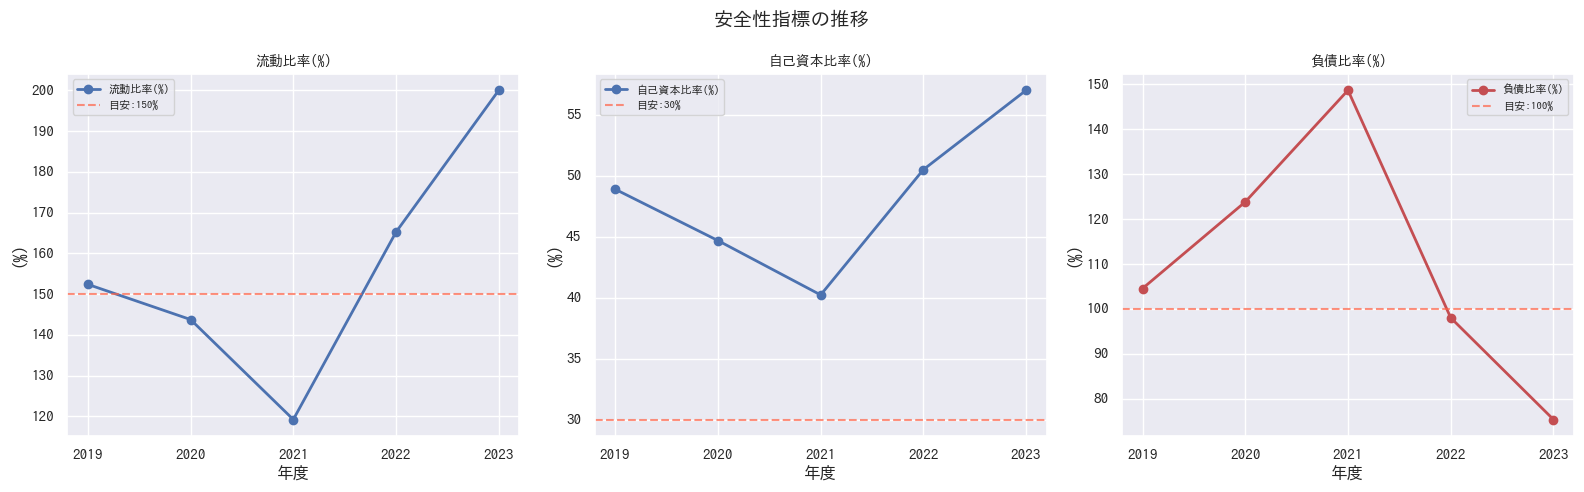

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

safety_config = [
    ("流動比率(%)",     150, "目安:150%", "#4C72B0"),
    ("自己資本比率(%)", 30,  "目安:30%",  "#4C72B0"),
    ("負債比率(%)",     100, "目安:100%", "#C44E52"),
]

for ax, (col, bm, bm_label, color) in zip(axes, safety_config):
    plot_trend_ax(ax, YEARS, df_ratios[col].values, col, bm, bm_label, color)

plt.suptitle("安全性指標の推移", fontsize=14)
plt.tight_layout()
plt.show()

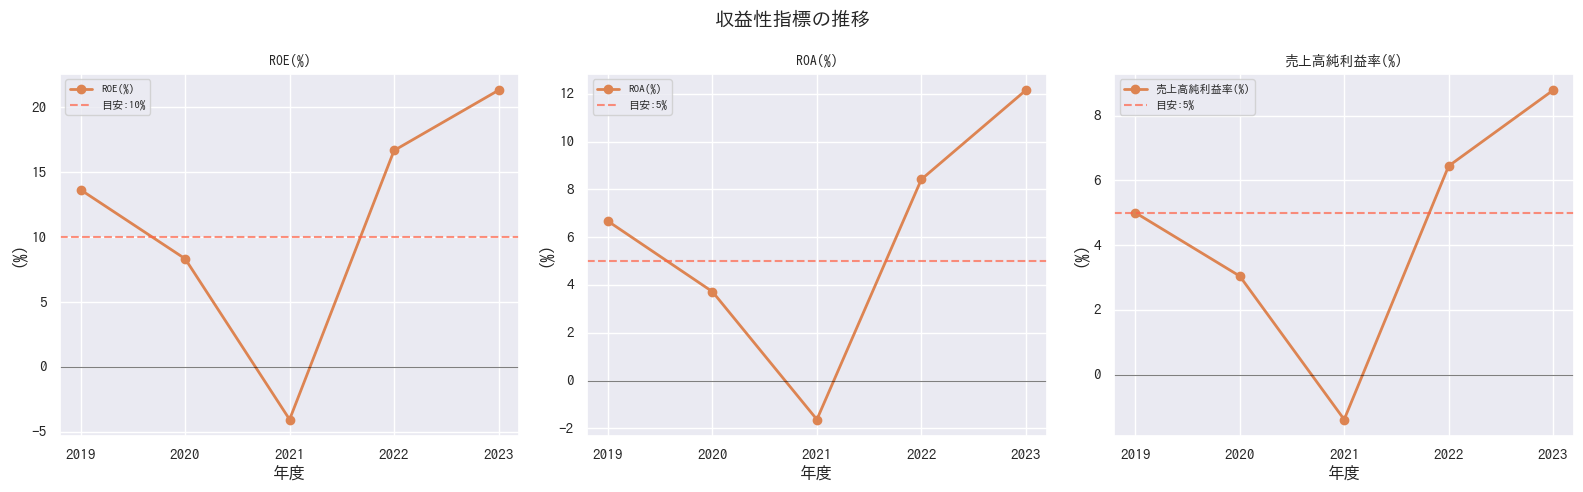

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

profit_config = [
    ("ROE(%)",            10, "目安:10%", "#DD8452"),
    ("ROA(%)",            5,  "目安:5%",  "#DD8452"),
    ("売上高純利益率(%)", 5,  "目安:5%",  "#DD8452"),
]

for ax, (col, bm, bm_label, color) in zip(axes, profit_config):
    plot_trend_ax(ax, YEARS, df_ratios[col].values, col, bm, bm_label, color)

plt.suptitle("収益性指標の推移", fontsize=14)
plt.tight_layout()
plt.show()

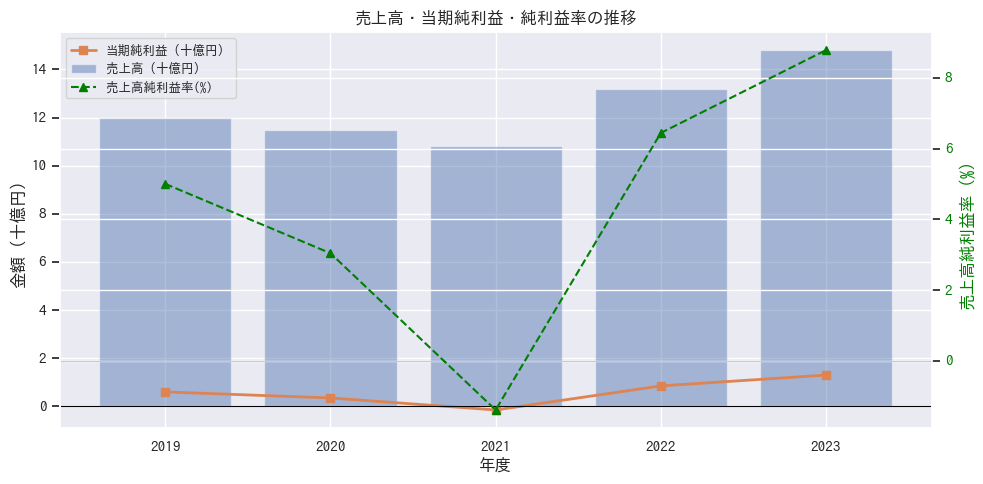

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(YEARS, df_pl["売上高"] / 1e3, alpha=0.45, color="#4C72B0", label="売上高（十億円）")
ax1.plot(YEARS, df_pl["当期純利益"] / 1e3, marker='s', color="#DD8452",
         linewidth=2, label="当期純利益（十億円）")
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xlabel("年度")
ax1.set_ylabel("金額（十億円）")
ax1.set_xticks(YEARS)

ax2.plot(YEARS, df_ratios["売上高純利益率(%)"].values, marker='^', color="green",
         linestyle='--', linewidth=1.5, label="売上高純利益率(%)")
ax2.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax2.set_ylabel("売上高純利益率（%）", color="green")
ax2.tick_params(axis='y', labelcolor='green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title("売上高・当期純利益・純利益率の推移")
plt.tight_layout()
plt.show()

---

## **4. レーダーチャートで財務健全性を比較する**

---

6つの指標をまとめて比較するために、**レーダーチャート（クモの巣グラフ）**を使います。

指標ごとにスケールが異なるため、各指標を「目安値を100%としたときの達成率」に正規化します：

$$\text{スコア} = \max\left(0, \min\left(1, \frac{\text{実績値}}{\text{目安値}}\right)\right)$$

負債比率だけは「低いほど良い」ため、逆数で計算します：

$$\text{負債比率スコア} = \max\left(0, \min\left(1, \frac{\text{目安値}}{\text{実績値}}\right)\right)$$

外側（1.0）に近いほど健全、中心（0）に近いほど要注意です。2019・2021・2023年の3年を重ねて、苦境と回復の変化を見てみましょう。

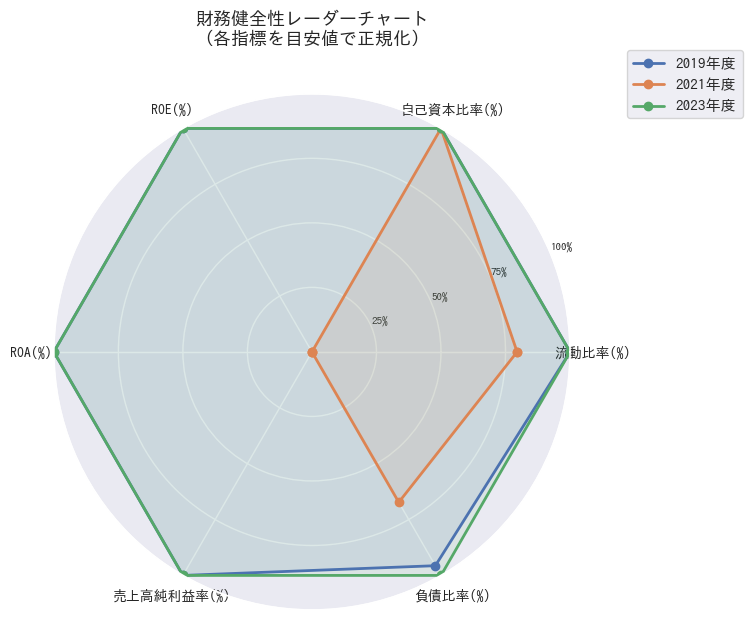

In [7]:
BENCHMARKS = {
    "流動比率(%)": {"target": 150, "higher_better": True},
    "自己資本比率(%)": {"target": 30, "higher_better": True},
    "ROE(%)": {"target": 10, "higher_better": True},
    "ROA(%)": {"target": 5, "higher_better": True},
    "売上高純利益率(%)": {"target": 5, "higher_better": True},
    "負債比率(%)": {"target": 100, "higher_better": False},
}

def normalize_ratio(value, target, higher_better):
    """比率を0〜1のスコアに正規化する（負債比率など低い方が良い指標は逆数）"""
    if higher_better:
        return max(0.0, min(1.0, value / target))
    else:
        if value <= 0:
            return 1.0
        return max(0.0, min(1.0, target / value))

categories = list(BENCHMARKS.keys())
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

colors_radar = {2019: "#4C72B0", 2021: "#DD8452", 2023: "#55A868"}

for year in [2019, 2021, 2023]:
    row = df_ratios.loc[year]
    scores = [normalize_ratio(row[cat], BENCHMARKS[cat]["target"],
                              BENCHMARKS[cat]["higher_better"])
              for cat in categories]
    scores += scores[:1]
    ax.plot(angles, scores, 'o-', linewidth=2,
            label=f"{year}年度", color=colors_radar[year])
    ax.fill(angles, scores, alpha=0.1, color=colors_radar[year])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8)
ax.set_title("財務健全性レーダーチャート\n（各指標を目安値で正規化）", size=13, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.show()

---

## **5. 健全性スコアリングと警告フラグ**

---

各指標が「許容できる水準」を満たしているかを判定し、**健全性スコア（6点満点）**を計算します。

| スコア | 評価 |
|--------|------|
| 6点 | 優良 |
| 4〜5点 | 良好 |
| 2〜3点 | 要注意 |
| 0〜1点 | 危険 |

目安値よりやや厳しく設定した「しきい値」を使って判定します。たとえば流動比率の目安は150%ですが、120%を下回ると警告とします。

In [8]:
THRESHOLDS = {
    "流動比率(%)": {"threshold": 120, "direction": "higher"},
    "自己資本比率(%)": {"threshold": 25, "direction": "higher"},
    "負債比率(%)": {"threshold": 150, "direction": "lower"},
    "ROE(%)": {"threshold": 5, "direction": "higher"},
    "ROA(%)": {"threshold": 2, "direction": "higher"},
    "売上高純利益率(%)": {"threshold": 2, "direction": "higher"},
}

def score_year(row: pd.Series) -> pd.DataFrame:
    """1年分の財務比率に対して各指標の合否を判定する"""
    results = []
    for ratio, rules in THRESHOLDS.items():
        value = row[ratio]
        if rules["direction"] == "higher":
            passed = value >= rules["threshold"]
            threshold_str = f">= {rules['threshold']}%"
        else:
            passed = value <= rules["threshold"]
            threshold_str = f"<= {rules['threshold']}%"
        results.append({
            "指標": ratio,
            "実績値": f"{value:.1f}%",
            "基準": threshold_str,
            "判定": "✓ 合格" if passed else "✗ 警告",
        })
    return pd.DataFrame(results)

def total_score(row: pd.Series) -> int:
    """合格指標の数（健全性スコア）を返す"""
    score = 0
    for ratio, rules in THRESHOLDS.items():
        v = row[ratio]
        if rules["direction"] == "higher" and v >= rules["threshold"]:
            score += 1
        elif rules["direction"] == "lower" and v <= rules["threshold"]:
            score += 1
    return score

df_ratios["健全性スコア"] = df_ratios.apply(total_score, axis=1)

print("=== 年度別 健全性スコア（6点満点）===")
for year in YEARS:
    score = df_ratios.loc[year, "健全性スコア"]
    if score == 6:    grade = "優良"
    elif score >= 4:  grade = "良好"
    elif score >= 2:  grade = "要注意"
    else:             grade = "危険"
    bar = "★" * score + "☆" * (6 - score)
    print(f"  {year}年度: {bar}  {score}/6点 ({grade})")

=== 年度別 健全性スコア（6点満点）===
  2019年度: ★★★★★★  6/6点 (優良)
  2020年度: ★★★★★★  6/6点 (優良)
  2021年度: ★★☆☆☆☆  2/6点 (要注意)
  2022年度: ★★★★★★  6/6点 (優良)
  2023年度: ★★★★★★  6/6点 (優良)


In [9]:
for year in [2021, 2023]:
    print(f"\n{'='*48}")
    print(f"  {year}年度 詳細スコアカード")
    print(f"{'='*48}")
    print(score_year(df_ratios.loc[year]).to_string(index=False))


  2021年度 詳細スコアカード
        指標    実績値      基準   判定
   流動比率(%) 119.2% >= 120% ✗ 警告
 自己資本比率(%)  40.2%  >= 25% ✓ 合格
   負債比率(%) 148.7% <= 150% ✓ 合格
    ROE(%)  -4.0%   >= 5% ✗ 警告
    ROA(%)  -1.6%   >= 2% ✗ 警告
売上高純利益率(%)  -1.4%   >= 2% ✗ 警告

  2023年度 詳細スコアカード
        指標    実績値      基準   判定
   流動比率(%) 200.0% >= 120% ✓ 合格
 自己資本比率(%)  57.0%  >= 25% ✓ 合格
   負債比率(%)  75.4% <= 150% ✓ 合格
    ROE(%)  21.3%   >= 5% ✓ 合格
    ROA(%)  12.2%   >= 2% ✓ 合格
売上高純利益率(%)   8.8%   >= 2% ✓ 合格


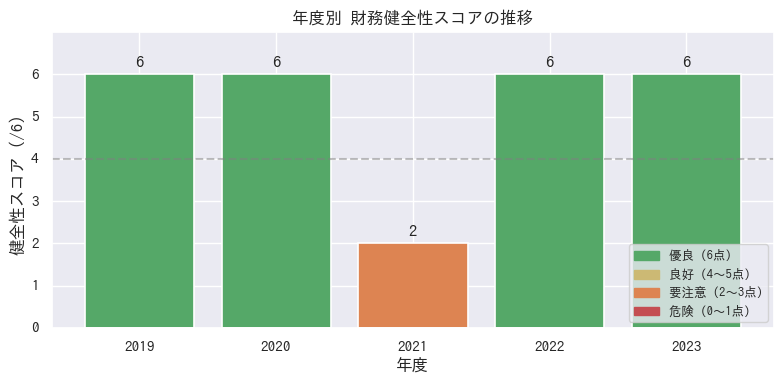

In [10]:
score_colors = []
for score in df_ratios["健全性スコア"]:
    if score == 6:    score_colors.append("#55A868")
    elif score >= 4:  score_colors.append("#CCB974")
    elif score >= 2:  score_colors.append("#DD8452")
    else:             score_colors.append("#C44E52")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(YEARS, df_ratios["健全性スコア"],
              color=score_colors, edgecolor='white', linewidth=1.2)

ax.set_ylim(0, 7)
ax.set_yticks(range(7))
ax.set_xlabel("年度")
ax.set_ylabel("健全性スコア（/6）")
ax.set_title("年度別 財務健全性スコアの推移")
ax.set_xticks(YEARS)
ax.axhline(4, linestyle='--', color='gray', alpha=0.5, label='良好ライン(4点)')

for bar, score in zip(bars, df_ratios["健全性スコア"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(score), ha='center', va='bottom', fontweight='bold')

legend_patches = [
    mpatches.Patch(color="#55A868", label="優良 (6点)"),
    mpatches.Patch(color="#CCB974", label="良好 (4〜5点)"),
    mpatches.Patch(color="#DD8452", label="要注意 (2〜3点)"),
    mpatches.Patch(color="#C44E52", label="危険 (0〜1点)"),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

---

## **6. 総合ダッシュボード（全指標一覧）**

---

最後に、全6指標を1つのダッシュボードにまとめます。各比率の推移・目安との乖離・健全性スコア・P/L概要が一画面で確認できます。

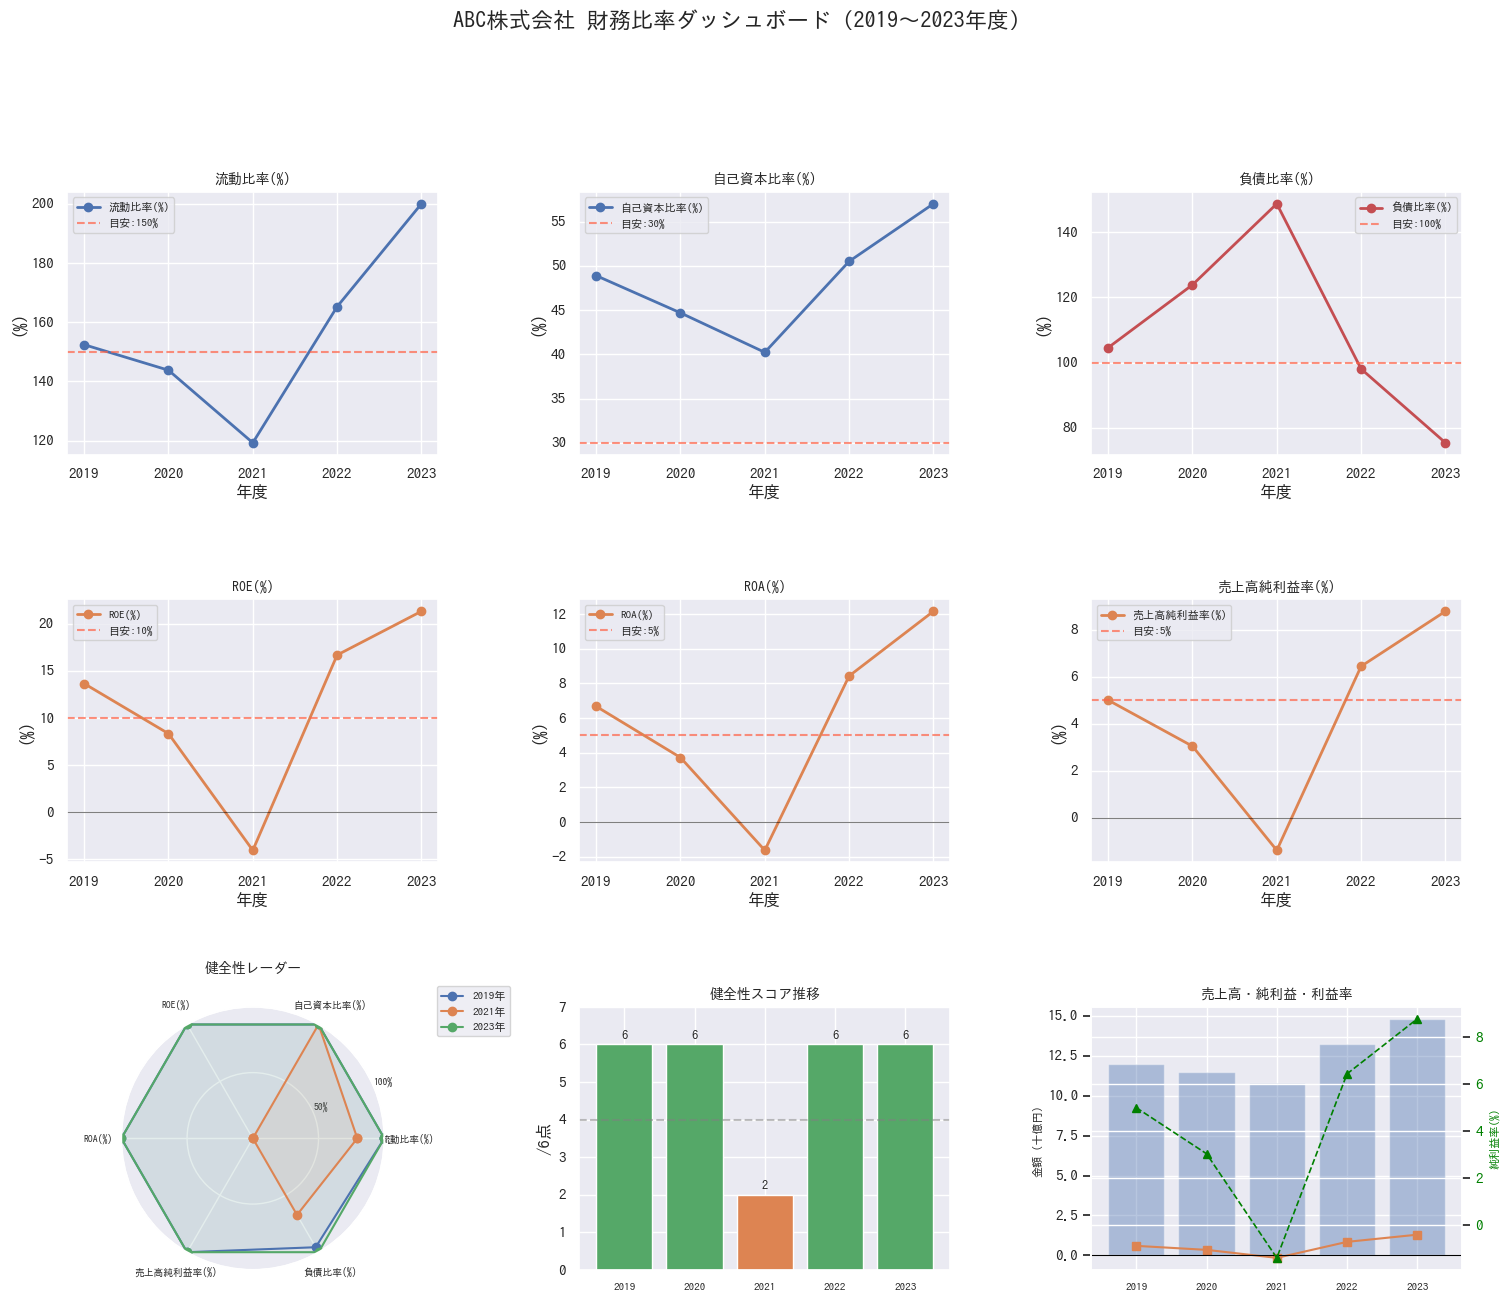

In [11]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# --- 行1: 安全性指標 ---
for i, (col, bm, color) in enumerate([
    ("流動比率(%)", 150, "#4C72B0"),
    ("自己資本比率(%)", 30, "#4C72B0"),
    ("負債比率(%)", 100, "#C44E52"),
]):
    ax = fig.add_subplot(gs[0, i])
    plot_trend_ax(ax, YEARS, df_ratios[col].values, col, bm, f"目安:{bm}%", color)

# --- 行2: 収益性指標 ---
for i, (col, bm) in enumerate([
    ("ROE(%)", 10),
    ("ROA(%)", 5),
    ("売上高純利益率(%)", 5),
]):
    ax = fig.add_subplot(gs[1, i])
    plot_trend_ax(ax, YEARS, df_ratios[col].values, col, bm, f"目安:{bm}%", "#DD8452")

# --- 行3左: レーダーチャート ---
ax_r = fig.add_subplot(gs[2, 0], projection='polar')
for year, color in [(2019, "#4C72B0"), (2021, "#DD8452"), (2023, "#55A868")]:
    row = df_ratios.loc[year]
    scores = [normalize_ratio(row[cat], BENCHMARKS[cat]["target"],
                              BENCHMARKS[cat]["higher_better"]) for cat in categories]
    scores += scores[:1]
    ax_r.plot(angles, scores, 'o-', linewidth=1.5, label=f"{year}年", color=color)
    ax_r.fill(angles, scores, alpha=0.08, color=color)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(categories, fontsize=7)
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.5, 1.0])
ax_r.set_yticklabels(["50%", "100%"], fontsize=7)
ax_r.set_title("健全性レーダー", size=10, y=1.10)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1), fontsize=8)

# --- 行3中: 健全性スコアバー ---
ax_s = fig.add_subplot(gs[2, 1])
b = ax_s.bar(YEARS, df_ratios["健全性スコア"], color=score_colors,
              edgecolor='white', linewidth=1.0)
ax_s.set_ylim(0, 7)
ax_s.set_xticks(YEARS)
ax_s.tick_params(axis='x', labelsize=8)
ax_s.axhline(4, linestyle='--', color='gray', alpha=0.5)
for bar, score in zip(b, df_ratios["健全性スコア"]):
    ax_s.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
              str(score), ha='center', va='bottom', fontweight='bold', fontsize=9)
ax_s.set_title("健全性スコア推移", fontsize=10)
ax_s.set_ylabel("/6点")

# --- 行3右: P/L概要 ---
ax_p = fig.add_subplot(gs[2, 2])
ax_p2 = ax_p.twinx()
ax_p.bar(YEARS, df_pl["売上高"] / 1e3, alpha=0.4, color="#4C72B0")
ax_p.plot(YEARS, df_pl["当期純利益"] / 1e3, marker='s', color="#DD8452", linewidth=1.5)
ax_p.axhline(0, color='black', linewidth=0.8)
ax_p.set_xticks(YEARS)
ax_p.tick_params(axis='x', labelsize=8)
ax_p.set_ylabel("金額（十億円）", fontsize=8)
ax_p2.plot(YEARS, df_ratios["売上高純利益率(%)"].values, marker='^',
           color="green", linestyle='--', linewidth=1.2)
ax_p2.set_ylabel("純利益率(%)", color="green", fontsize=8)
ax_p2.tick_params(axis='y', labelcolor='green')
ax_p.set_title("売上高・純利益・利益率", fontsize=10)

fig.suptitle("ABC株式会社 財務比率ダッシュボード（2019〜2023年度）",
             fontsize=16, y=1.01)
plt.show()

---

## **まとめ**

---

ABC株式会社の5年間を振り返ると、こんなストーリーが見えてきます：

- **2019〜2020年**: 収益性がやや低下しつつも、安全性は概ね維持。健全性スコアは4点台で「良好」圏
- **2021年**: コスト増と売上減が重なり当期純利益が**赤字**に転落。ROE・ROAがマイナスになり、自己資本も目減り。健全性スコアは2点まで落ち「要注意」圏に
- **2022〜2023年**: 売上が急回復し収益性も大幅改善。2023年度は健全性スコア6点満点の「優良」評価を達成

財務比率を使う際のポイントをまとめると：

- **単年の数字より「トレンド」を見る** — 一時的な悪化か、構造的な問題かを区別することが重要
- **安全性と収益性はセットで評価する** — 利益が出ていても資金繰りが苦しければ危険だし、逆に利益が低くても財務基盤が強ければ問題ない場合もある
- **比率は入口に過ぎない** — ROICや有利子負債EBITDA倍率、フリーキャッシュフローなど、より高度な指標にも今回と同じ考え方を応用できる

数字の裏にある「経営のストーリー」を読むのが、財務分析の醍醐味です。